In [2]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../MERS/')
from fg_model import *
from SEDfitting import *
from beam_model import *

Load the sky model

In [3]:
Mel_model = SynchrotronExtrapolator()

Mel_ff_model = FreeFreeExtrapolator()

Load beams

- RHINO beam (55 - 85 MHz)
- Gaussian beam (Achromatic; 50 - 200 MHz)
- Airy beam (Chromatic; 50 - 200 MHz)


SVD beam:

- $u[:, i] = s_i(\nu)$
- $vh[i, :] = B_i(p)$

In [3]:
# Achromatic Airy Beam

freq_list = np.linspace(50, 200, 101)

Gau_Ach_beam = Achromatic_Gaussian_Beam(50, 101, nside=512)
Gau_Ach_beam.get_beam_l()
Gau_Ach_beam_window = Gau_Ach_beam.bl_list

del Gau_Ach_beam

In [4]:
# Chromatic Airy Beam

freq_list = np.linspace(50, 200, 101)

Airy_ch_beam = Circular_Aperture_Gaussian_Envolope(first_null_200_mhz_deg=50, freq_array_mhz = freq_list, nside=512)
Airy_ch_beam.get_beam_l()
Airy_ch_beam_window = Airy_ch_beam.bl_list

# SVD 
Airy_ch_U, Airy_ch_S, Airy_ch_Vt = Airy_ch_beam.generate_SVD_beams()

# BCF
ref_beam_window = Airy_ch_beam.bl_list[50]
ref_map = Mel_model.map(freq_list[50]) + Mel_ff_model.map(freq_list[50])
Airy_ch_BCF_cube = np.array(Airy_ch_beam.generate_BCF(ref_map, ref_beam_window))

del Airy_ch_beam

: 

In [ ]:
RHINO_freq_list = np.arange(55.0, 85.0+0.5, 0.5)

# Load the RHINO wet soil beam
RHINO_wet = RhinoBeam(filepath='/Users/zzhang/Downloads/HornWet/')
RHINO_wet.get_beam_l()
RHINO_beam_window = RHINO_wet.bl_list

# SVD 
RHINO_U, RHINO_S, RHINO_Vh = RHINO_wet.generate_SVD_beams()

# BCF
ref_beam_window = RHINO_wet.bl_list[30]
ref_map = Mel_model.map(RHINO_freq_list[30]) + Mel_ff_model.map(RHINO_freq_list[30])
RHINO_BCF_cube = np.array(RHINO_wet.generate_BCF(ref_map, ref_beam_window))

del RHINO_wet

Generate the beam-convolved radio sky 

In [ ]:
# Generate the beam convolved Mel maps
CNN_PL_Gau = Mel_model.map(freq_list, beam_transfer=Gau_Ach_beam_window) + Mel_ff_model.map(freq_list, beam_transfer=Gau_Ach_beam_window)
CNN_PL_Air = Mel_model.map(freq_list, beam_transfer=Airy_ch_beam_window) + Mel_ff_model.map(freq_list, beam_transfer=Airy_ch_beam_window)
CNN_PL_RHINO = Mel_model.map(RHINO_freq_list, beam_transfer=RHINO_beam_window) + Mel_ff_model.map(RHINO_freq_list, beam_transfer=RHINO_beam_window)
CNN_PL_Gau_rhino_freq = Mel_model.map(RHINO_freq_list, beam_transfer=Gau_Ach_beam_window[:61]) + Mel_ff_model.map(RHINO_freq_list, beam_transfer=Gau_Ach_beam_window[:61])
# CNN_PL_RHINO_ach = Mel_model.map(RHINO_freq_list, beam_transfer=[RHINO_beam_window[0]]*61) + Mel_ff_model.map(RHINO_freq_list, beam_transfer=[RHINO_beam_window[0]]*61)


Beam SVD modes (RHINO)

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


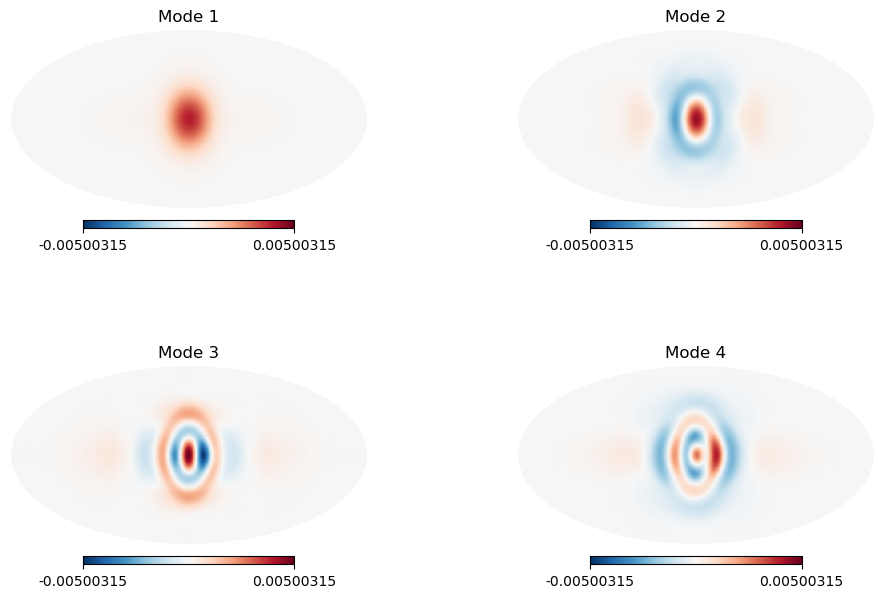

In [7]:
plot_svd_beam_modes(RHINO_Vh, nest=False)

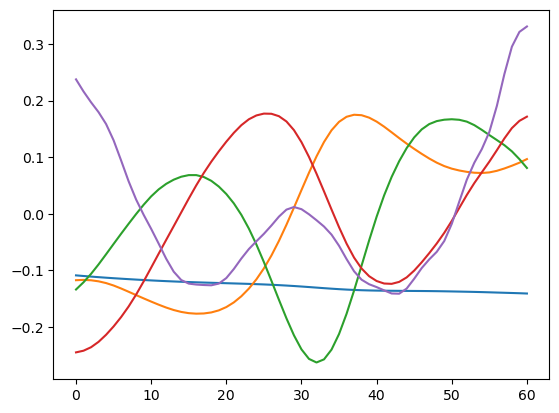

In [8]:
plt.plot(RHINO_U[:, :5])

Beam SVD modes (Airy)

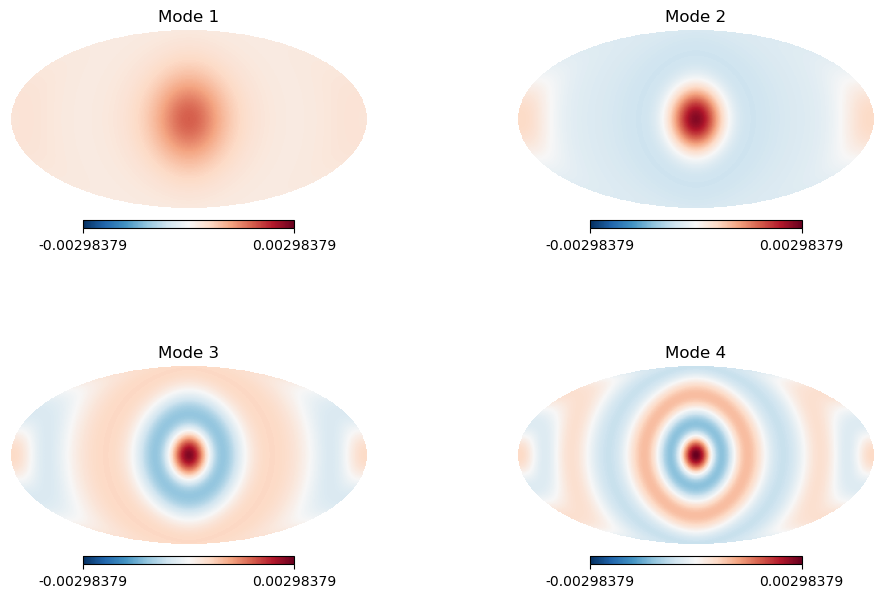

In [9]:
plot_svd_beam_modes(Airy_ch_Vt, nest=False)

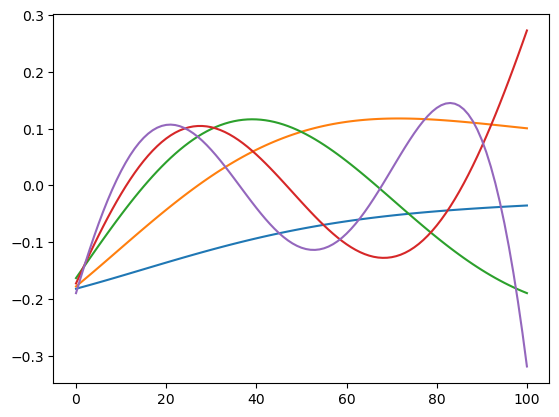

In [10]:
plt.plot(Airy_ch_U[:, :5])

### Timestream of the zenith  
LSTs → (RA, Dec) → Galactic (l, b) → HEALPix pixel index

In [ ]:
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
from astropy.time import Time
import astropy.units as u
import healpy as hp

# === JBO site ===
lat = 53.23625  # degrees
lon = -2.30744  # degrees
location = EarthLocation(lat=lat*u.deg, lon=lon*u.deg)

# === Generate obs_time list（UTC）===
# From 2024-10-01 22:00 to 2024-10-02 05:00，every "delta_minutes" minute
start_time = Time('2024-10-01 22:00:00', scale='utc', location=location)
end_time   = Time('2024-10-02 05:00:00', scale='utc', location=location)
delta_minutes = 2

# Construct the time sequence
times = start_time + np.arange(0, (end_time - start_time).to_value('min') + delta_minutes, delta_minutes) * u.min

# === Calculate the corresponding LSTs ===
lst_array = times.sidereal_time('mean', longitude=lon*u.deg)

# === Constants ===
nside = 512  # HEALPix resolution
lat = 53.23625  # JBO latitude in degrees

# === Step 1: LSTs → (RA, Dec) for zenith ===
# Dec of zenith = latitude
dec_zenith = lat * u.deg
ra_zeniths = lst_array.to(u.deg)  # LST is the RA of the zenith

# === Step 2: Convert to Galactic coordinates ===
skycoords_eq = SkyCoord(ra=ra_zeniths, dec=dec_zenith, frame='icrs')
skycoords_gal = skycoords_eq.galactic

# === Step 3: Convert to HEALPix pixel indices ===
# Use vector representation to feed into healpy
vecs = skycoords_gal.represent_as('cartesian').get_xyz().value  # shape: (3, N)
pix_indices = hp.vec2pix(nside, vecs[0], vecs[1], vecs[2])

# === Example output ===
for time, lst, pix in zip(times[:5], lst_array[:5], pix_indices[:5]):
    print(f"UTC: {time.iso} | LST: {lst.to_string(unit=u.hour)} | HEALPix pixel: {pix}")


UTC: 2024-10-01 22:00:00.000 | LST: 22h35m15.91468459s | HEALPix pixel: 1691211
UTC: 2024-10-01 22:02:00.000 | LST: 22h37m16.24323363s | HEALPix pixel: 1697357
UTC: 2024-10-01 22:04:00.000 | LST: 22h39m16.57178268s | HEALPix pixel: 1699406
UTC: 2024-10-01 22:06:00.000 | LST: 22h41m16.90033172s | HEALPix pixel: 1705552
UTC: 2024-10-01 22:08:00.000 | LST: 22h43m17.22888076s | HEALPix pixel: 1707601


### Generate timestream of data (foreground components only)
shape: (n_LST, n_freqs)

In [12]:
Gau_TOD = CNN_PL_Gau[pix_indices, :]
Air_TOD = CNN_PL_Air[pix_indices, :]
Rhino_TOD = CNN_PL_RHINO[pix_indices, :]
Gau_RHINO_freqs_TOD = CNN_PL_Gau_rhino_freq[pix_indices, :]
# Rhino_ach_TOD = CNN_PL_RHINO_ach[pix_indices, :]

Airy_ch_BCF_cube = Airy_ch_BCF_cube[pix_indices, :]
RHINO_BCF_cube = RHINO_BCF_cube[pix_indices, :]

spec_ind_tod = Mel_model.specidx_map[pix_indices]

# # Present the waterfall of the tod_sim
# plt.figure(figsize=(12, 6))
# plt.imshow(tod_sim, aspect='auto', origin='lower', 
#            extent=[0, tod_sim.shape[1], 0, tod_sim.shape[0]])
# plt.xlabel('Time Samples')
# plt.ylabel('Pixel Index')
# plt.colorbar(label='Intensity (arb. units)')
# plt.title('TOD Waterfall Plot')
# plt.show()

In [13]:
n_order = 8

coeffs_Gau_fix, loss_Gau_fix = fit_fg_cube(Gau_TOD, spec_ind_tod, freq_list, nu_ref=None, 
                                           max_order=n_order, adaptive_pivot=False)
coeffs_Gau_adp, loss_Gau_adp, piv_Gau_adp = fit_fg_cube(Gau_TOD, spec_ind_tod, freq_list, nu_ref=None, 
                                                        max_order=n_order, adaptive_pivot=True)


/Users/zzhang/Workspace/MERS/notebooks/../MERS/SEDfitting.py:233: RuntimeWarning: overflow encountered in exp
  xs_beta0 = np.exp(self.log_xs*beta0)
/opt/homebrew/Caskroom/miniconda/base/envs/astro_env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2780: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/zzhang/Workspace/MERS/notebooks/../MERS/SEDfitting.py:252: RuntimeWarning: invalid value encountered in divide
  result /= norms[np.newaxis, :]  # Normalize each column by its l2-norm


In [14]:

coeffs_Gau_rhino_freqs_fix, loss_Gau_rhino_freqs_fix = fit_fg_cube(Gau_RHINO_freqs_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                    max_order=n_order, adaptive_pivot=False)
coeffs_Gau_rhino_freqs_adp, loss_Gau_rhino_freqs_adp, piv_Gau_rhino_freqs_adp = fit_fg_cube(Gau_RHINO_freqs_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                                            max_order=n_order, adaptive_pivot=True)


Processing pixels:   0%|          | 0/212 [00:00<?, ?it/s]/Users/zzhang/Workspace/MERS/notebooks/../MERS/SEDfitting.py:233: RuntimeWarning: overflow encountered in exp
  xs_beta0 = np.exp(self.log_xs*beta0)
/opt/homebrew/Caskroom/miniconda/base/envs/astro_env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2780: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/zzhang/Workspace/MERS/notebooks/../MERS/SEDfitting.py:252: RuntimeWarning: invalid value encountered in divide
  result /= norms[np.newaxis, :]  # Normalize each column by its l2-norm
/Users/zzhang/Workspace/MERS/notebooks/../MERS/SEDfitting.py:233: RuntimeWarning: overflow encountered in exp
  xs_beta0 = np.exp(self.log_xs*beta0)
/opt/homebrew/Caskroom/miniconda/base/envs/astro_env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2780: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/Users/zzhang/Workspace/MERS/notebooks/../MERS/SEDfitting.py:252: RuntimeWarnin

In [15]:
# coeffs_RHINO_ach_fix, loss_RHINO_ach_fix = fit_fg_cube(Rhino_ach_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None, 
#                                                         max_order=n_order, adaptive_pivot=False)
# coeffs_RHINO_ach_adp, loss_RHINO_ach_adp, pivot_RHINO_ach_adp = fit_fg_cube(Rhino_ach_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
#                                                                           max_order=n_order, adaptive_pivot=True)

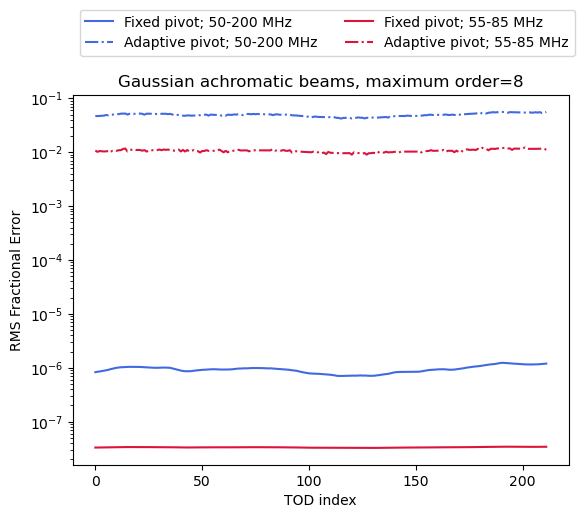

In [16]:
plt.plot(loss_Gau_fix, label='Fixed pivot; 50-200 MHz', color='royalblue')
plt.plot(loss_Gau_adp, label='Adaptive pivot; 50-200 MHz', linestyle='-.', color='royalblue')
plt.plot(loss_Gau_rhino_freqs_fix, label='Fixed pivot; 55-85 MHz', color='crimson')
plt.plot(loss_Gau_rhino_freqs_adp, label='Adaptive pivot; 55-85 MHz', linestyle='-.', color='crimson')
# plt.plot(loss_RHINO_ach_fix, label='RHINO; Fixed pivot; 55-85 MHz', color='forestgreen')
# plt.plot(loss_RHINO_ach_adp, label='RHINO; Adaptive pivot; 55-85 MHz', linestyle='-.', color='forestgreen')

# Set the region above 0.002 to be gray
# plt.gca().axhspan(ymin=0.002, ymax=1, facecolor='gray', alpha=0.3)
# plt.ylim(0.00001, 1.1*np.max(loss_tod_adapted))
plt.yscale('log')
plt.ylabel('RMS Fractional Error')
plt.xlabel('TOD index')
plt.title('Gaussian achromatic beams, maximum order=8')
plt.legend(bbox_to_anchor=(0.0, 1.25), loc='upper left', ncol=2)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the global 21cm signal freq-freq covariance matrix
cov_gs_55_85 = np.load('signal_cov_55_85.npy')
cov_gs_50_200 = np.load('signal_cov_50_200.npy')
GS_object_55_85 = Global_21cm_extraction(RHINO_freq_list)
GS_object_50_200 = Global_21cm_extraction(freq_list)


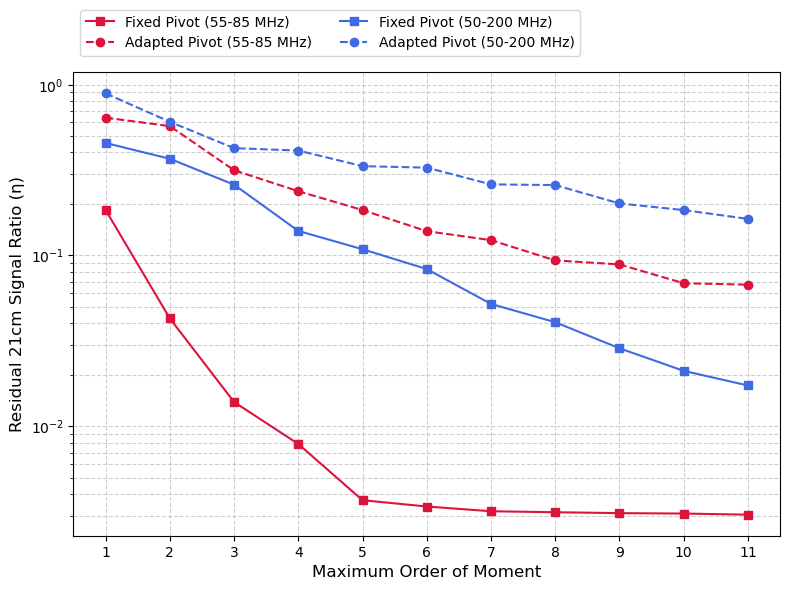

In [18]:
eta_adapted_50_200=[]
eta_fixed_50_200=[]
eta_adapted_55_85=[]
eta_fixed_55_85=[]

orders_li = np.arange(1, 12, 1)
for n in orders_li:
    eta_adapted_50_200.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=True))
    eta_fixed_50_200.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=False))
    eta_adapted_55_85.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=True))
    eta_fixed_55_85.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=False))

# Visualization
plt.figure(figsize=(8, 6))
plt.semilogy(orders_li, eta_fixed_55_85, 's-', label='Fixed Pivot (55-85 MHz)', color='crimson')
plt.semilogy(orders_li, eta_adapted_55_85, 'o--', label='Adapted Pivot (55-85 MHz)', color='crimson')
plt.semilogy(orders_li, eta_fixed_50_200,'s-', label='Fixed Pivot (50-200 MHz)', color='royalblue')
plt.semilogy(orders_li, eta_adapted_50_200, 'o--', label='Adapted Pivot (50-200 MHz)', color='royalblue')

plt.xlabel('Maximum Order of Moment', fontsize=12)
plt.ylabel('Residual 21cm Signal Ratio (η)', fontsize=12)
#plt.title('Foreground Subtraction Efficiency', fontsize=14)
plt.xticks(orders_li)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(0.0, 1.15), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

**Observation:** 

In [39]:
n_order = 8
coeffs_Air_fix, loss_Air_fix = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                           max_order=n_order, adaptive_pivot=False)

coeffs_Air_adp, loss_Air_adp, piv_Air_adp = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                        max_order=n_order, adaptive_pivot=True)

coeffs_Air_fix_BCF, loss_Air_fix_BCF = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=False, BCF=Airy_ch_BCF_cube)
coeffs_Air_adp_BCF, loss_Air_adp_BCF, piv_Air_adp_BCF = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCF=Airy_ch_BCF_cube)



n_beam = 3
coeffs_Air_fix_SVD3, loss_Air_fix_SVD3 = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=False, BCSVD=Airy_ch_U[:, :n_beam])
coeffs_Air_adp_SVD3, loss_Air_adp_SVD3, piv_Air_adp_SVD3 = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=Airy_ch_U[:, :n_beam])


n_beam = 4
coeffs_Air_fix_SVD4, loss_Air_fix_SVD4 = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=False, BCSVD=Airy_ch_U[:, :n_beam])
coeffs_Air_adp_SVD4, loss_Air_adp_SVD4, piv_Air_adp_SVD4 = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=Airy_ch_U[:, :n_beam])

n_beam = 5
coeffs_Air_fix_SVD5, loss_Air_fix_SVD5 = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=False, BCSVD=Airy_ch_U[:, :n_beam])
coeffs_Air_adp_SVD5, loss_Air_adp_SVD5, piv_Air_adp_SVD5 = fit_fg_cube(Air_TOD, spec_ind_tod, freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=Airy_ch_U[:, :n_beam])

/opt/homebrew/Caskroom/miniconda/base/envs/astro_env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2780: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real
/opt/homebrew/Caskroom/miniconda/base/envs/astro_env/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2780: RuntimeWarning: overflow encountered in multiply
  s = (x.conj() * x).real


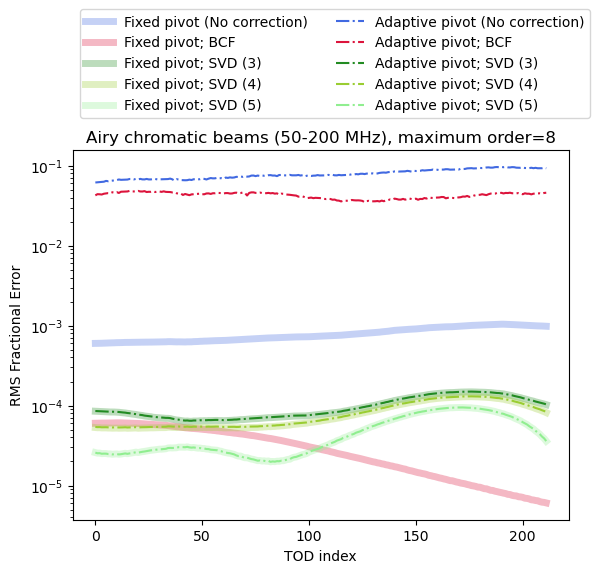

In [40]:
green_colors = ['forestgreen', 'yellowgreen', 'lightgreen', 'palegreen', 'yellowgreen', 'limegreen', 'greenyellow', 'green', 'darkgreen']

plt.plot(loss_Air_fix, label='Fixed pivot (No correction)', color='royalblue', lw = 5, alpha=0.3)
plt.plot(loss_Air_fix_BCF, label='Fixed pivot; BCF', color='crimson', lw = 5, alpha=0.3)
plt.plot(loss_Air_fix_SVD3, label='Fixed pivot; SVD (3)', color=green_colors[0], lw = 5, alpha=0.3)
plt.plot(loss_Air_fix_SVD4, label='Fixed pivot; SVD (4)', color=green_colors[1], lw = 5, alpha=0.3)
plt.plot(loss_Air_fix_SVD5, label='Fixed pivot; SVD (5)', color=green_colors[2], lw = 5, alpha=0.3)

plt.plot(loss_Air_adp, label='Adaptive pivot (No correction)', linestyle='-.', color='royalblue')
plt.plot(loss_Air_adp_BCF, label='Adaptive pivot; BCF', linestyle='-.', color='crimson')
plt.plot(loss_Air_adp_SVD3, label='Adaptive pivot; SVD (3)', linestyle='-.', color=green_colors[0])
plt.plot(loss_Air_adp_SVD4, label='Adaptive pivot; SVD (4)', linestyle='-.', color=green_colors[1])
plt.plot(loss_Air_adp_SVD5, label='Adaptive pivot; SVD (5)', linestyle='-.', color=green_colors[2])

plt.yscale('log')
plt.ylabel('RMS Fractional Error')
plt.xlabel('TOD index')
plt.title('Airy chromatic beams (50-200 MHz), maximum order=8')
plt.legend(bbox_to_anchor=(0.0, 1.4), loc='upper left', ncol=2)

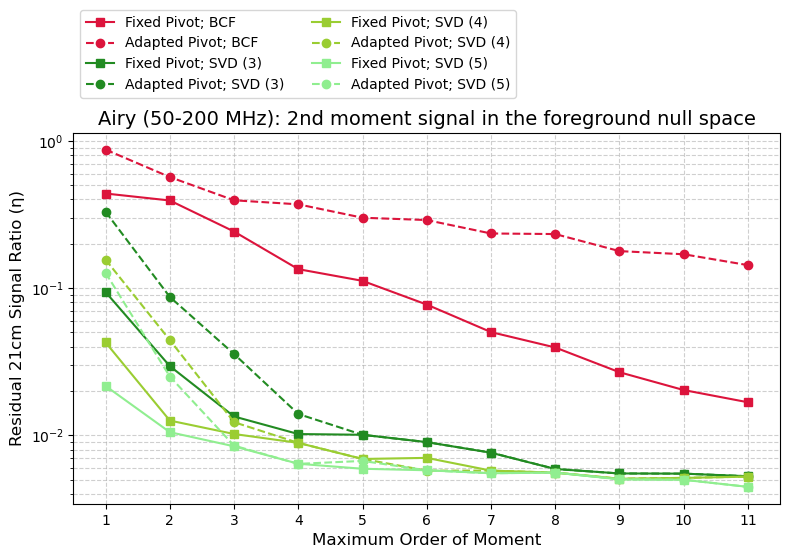

In [34]:
eta_adapted_Airy_BCF=[]
eta_fixed_Airy_BCF=[]
eta_adapted_Airy_SVD3=[]
eta_fixed_Airy_SVD3=[]
eta_adapted_Airy_SVD4=[]
eta_fixed_Airy_SVD4=[]
eta_adapted_Airy_SVD5=[]
eta_fixed_Airy_SVD5=[]

orders_li = np.arange(1, 12, 1)
for n in orders_li:
    eta_adapted_Airy_BCF.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=True, BCF=Airy_ch_BCF_cube))
    eta_fixed_Airy_BCF.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=False, BCF=Airy_ch_BCF_cube))
    eta_adapted_Airy_SVD3.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=True, BCSVD=Airy_ch_U[:, :3]))
    eta_fixed_Airy_SVD3.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=False, BCSVD=Airy_ch_U[:, :3]))
    eta_adapted_Airy_SVD4.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=True, BCSVD=Airy_ch_U[:, :4]))
    eta_fixed_Airy_SVD4.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=False, BCSVD=Airy_ch_U[:, :4]))
    eta_adapted_Airy_SVD5.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=True, BCSVD=Airy_ch_U[:, :5]))
    eta_fixed_Airy_SVD5.append(GS_object_50_200.variance_in_fg_null_space(cov_gs_50_200, -2.9, n, adaptive_pivot=False, BCSVD=Airy_ch_U[:, :5]))

# Visualization
plt.figure(figsize=(8, 6))
plt.semilogy(orders_li, eta_fixed_Airy_BCF, 's-', label='Fixed Pivot; BCF', color='crimson')
plt.semilogy(orders_li, eta_adapted_Airy_BCF, 'o--', label='Adapted Pivot; BCF', color='crimson')
plt.semilogy(orders_li, eta_fixed_Airy_SVD3,'s-', label='Fixed Pivot; SVD (3)', color=green_colors[0])
plt.semilogy(orders_li, eta_adapted_Airy_SVD3, 'o--', label='Adapted Pivot; SVD (3)', color=green_colors[0])
plt.semilogy(orders_li, eta_fixed_Airy_SVD4,'s-', label='Fixed Pivot; SVD (4)', color=green_colors[1])
plt.semilogy(orders_li, eta_adapted_Airy_SVD4, 'o--', label='Adapted Pivot; SVD (4)', color=green_colors[1])
plt.semilogy(orders_li, eta_fixed_Airy_SVD5,'s-', label='Fixed Pivot; SVD (5)', color=green_colors[2])
plt.semilogy(orders_li, eta_adapted_Airy_SVD5, 'o--', label='Adapted Pivot; SVD (5)', color=green_colors[2])


plt.xlabel('Maximum Order of Moment', fontsize=12)
plt.ylabel('Residual 21cm Signal Ratio (η)', fontsize=12)
plt.title('Airy (50-200 MHz): 2nd moment signal in the foreground null space', fontsize=14)
plt.xticks(orders_li)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(0.0, 1.35), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

In [25]:
########################

coeffs_Rhi_fix, loss_Rhi_fix = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                           max_order=n_order, adaptive_pivot=False)

coeffs_Rhi_adp, loss_Rhi_adp, piv_Rhi_adp = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                        max_order=n_order, adaptive_pivot=True)

coeffs_Rhi_fix_BCF, loss_Rhi_fix_BCF = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=False, BCF=RHINO_BCF_cube)

coeffs_Rhi_adp_BCF, loss_Rhi_adp_BCF, piv_Rhi_adp_BCF = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCF=RHINO_BCF_cube)

n_beam = 3
coeffs_Rhi_fix_SVD3, loss_Rhi_fix_SVD3 = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=False, BCSVD=RHINO_U[:, :n_beam])

coeffs_Rhi_adp_SVD3, loss_Rhi_adp_SVD3, piv_Rhi_adp_SVD3 = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=RHINO_U[:, :n_beam])

n_beam = 4
coeffs_Rhi_fix_SVD4, loss_Rhi_fix_SVD4 = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=False, BCSVD=RHINO_U[:, :n_beam])

coeffs_Rhi_adp_SVD4, loss_Rhi_adp_SVD4, piv_Rhi_adp_SVD4 = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=RHINO_U[:, :n_beam])

n_beam = 5
coeffs_Rhi_fix_SVD5, loss_Rhi_fix_SVD5 = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=False, BCSVD=RHINO_U[:, :n_beam])

coeffs_Rhi_adp_SVD5, loss_Rhi_adp_SVD5, piv_Rhi_adp_SVD5 = fit_fg_cube(Rhino_TOD, spec_ind_tod, RHINO_freq_list, nu_ref=None,
                                                                   max_order=n_order, adaptive_pivot=True, BCSVD=RHINO_U[:, :n_beam])


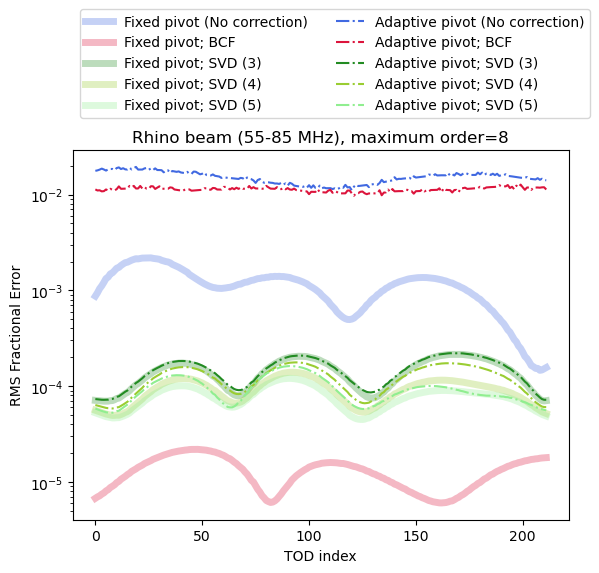

In [27]:
green_colors = ['forestgreen', 'yellowgreen', 'lightgreen', 'palegreen', 'yellowgreen', 'limegreen', 'greenyellow', 'green', 'darkgreen']

plt.plot(loss_Rhi_fix, label='Fixed pivot (No correction)', color='royalblue', lw = 5, alpha=0.3)
plt.plot(loss_Rhi_fix_BCF, label='Fixed pivot; BCF', color='crimson', lw = 5, alpha=0.3)
plt.plot(loss_Rhi_fix_SVD3, label='Fixed pivot; SVD (3)', color=green_colors[0], lw = 5, alpha=0.3)
plt.plot(loss_Rhi_fix_SVD4, label='Fixed pivot; SVD (4)', color=green_colors[1], lw = 5, alpha=0.3)
plt.plot(loss_Rhi_fix_SVD5, label='Fixed pivot; SVD (5)', color=green_colors[2], lw = 5, alpha=0.3)

plt.plot(loss_Rhi_adp, label='Adaptive pivot (No correction)', linestyle='-.', color='royalblue')
plt.plot(loss_Rhi_adp_BCF, label='Adaptive pivot; BCF', linestyle='-.', color='crimson')
plt.plot(loss_Rhi_adp_SVD3, label='Adaptive pivot; SVD (3)', linestyle='-.', color=green_colors[0])
plt.plot(loss_Rhi_adp_SVD4, label='Adaptive pivot; SVD (4)', linestyle='-.', color=green_colors[1])
plt.plot(loss_Rhi_adp_SVD5, label='Adaptive pivot; SVD (5)', linestyle='-.', color=green_colors[2])

plt.yscale('log')
plt.ylabel('RMS Fractional Error')
plt.xlabel('TOD index')
plt.title('Rhino beam (55-85 MHz), maximum order=8')
plt.legend(bbox_to_anchor=(0.0, 1.4), loc='upper left', ncol=2)

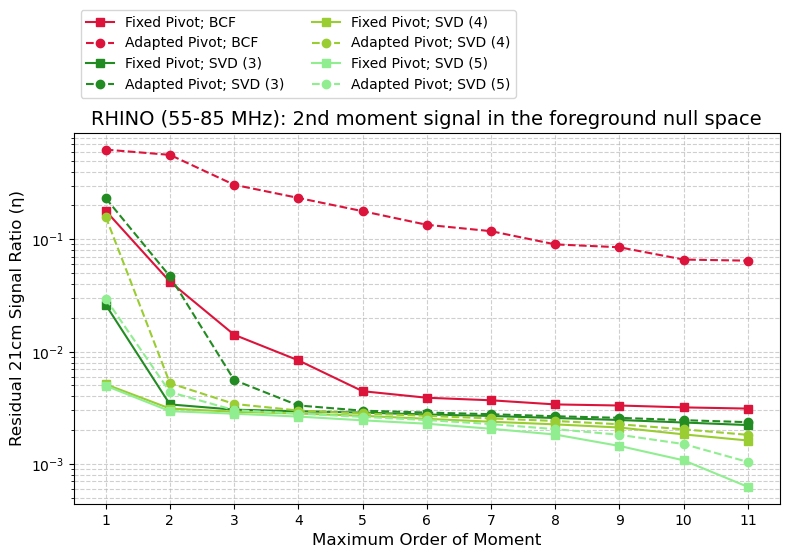

In [33]:
eta_adapted_Rhino_BCF=[]
eta_fixed_Rhino_BCF=[]
eta_adapted_Rhino_SVD3=[]
eta_fixed_Rhino_SVD3=[]
eta_adapted_Rhino_SVD4=[]
eta_fixed_Rhino_SVD4=[]
eta_adapted_Rhino_SVD5=[]
eta_fixed_Rhino_SVD5=[]

orders_li = np.arange(1, 12, 1)
for n in orders_li:
    eta_adapted_Rhino_BCF.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=True, BCF=RHINO_BCF_cube))
    eta_fixed_Rhino_BCF.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=False, BCF=RHINO_BCF_cube))
    eta_adapted_Rhino_SVD3.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=True, BCSVD=RHINO_U[:, :3]))
    eta_fixed_Rhino_SVD3.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=False, BCSVD=RHINO_U[:, :3]))
    eta_adapted_Rhino_SVD4.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=True, BCSVD=RHINO_U[:, :4]))
    eta_fixed_Rhino_SVD4.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=False, BCSVD=RHINO_U[:, :4]))
    eta_adapted_Rhino_SVD5.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=True, BCSVD=RHINO_U[:, :5]))
    eta_fixed_Rhino_SVD5.append(GS_object_55_85.variance_in_fg_null_space(cov_gs_55_85, -2.9, n, adaptive_pivot=False, BCSVD=RHINO_U[:, :5]))

# Visualization
plt.figure(figsize=(8, 6))
plt.semilogy(orders_li, eta_fixed_Rhino_BCF, 's-', label='Fixed Pivot; BCF', color='crimson')
plt.semilogy(orders_li, eta_adapted_Rhino_BCF, 'o--', label='Adapted Pivot; BCF', color='crimson')
plt.semilogy(orders_li, eta_fixed_Rhino_SVD3,'s-', label='Fixed Pivot; SVD (3)', color=green_colors[0])
plt.semilogy(orders_li, eta_adapted_Rhino_SVD3, 'o--', label='Adapted Pivot; SVD (3)', color=green_colors[0])
plt.semilogy(orders_li, eta_fixed_Rhino_SVD4,'s-', label='Fixed Pivot; SVD (4)', color=green_colors[1])
plt.semilogy(orders_li, eta_adapted_Rhino_SVD4, 'o--', label='Adapted Pivot; SVD (4)', color=green_colors[1])
plt.semilogy(orders_li, eta_fixed_Rhino_SVD5,'s-', label='Fixed Pivot; SVD (5)', color=green_colors[2])
plt.semilogy(orders_li, eta_adapted_Rhino_SVD5, 'o--', label='Adapted Pivot; SVD (5)', color=green_colors[2])


plt.xlabel('Maximum Order of Moment', fontsize=12)
plt.ylabel('Residual 21cm Signal Ratio (η)', fontsize=12)
plt.title('RHINO (55-85 MHz): 2nd moment signal in the foreground null space', fontsize=14)
plt.xticks(orders_li)
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(0.0, 1.35), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

### Signal projection

In [14]:
def projection_in_fg_null_space(obj, data, beta0_list, max_order, true_signal, 
                                    BCF_list=None,  
                                    BCSVD=None):
    '''
    Compute the projection of the data in the null space of the spectral moment basis.
    '''
    n_pix = data.shape[0]
    data_proj_ls = []
    true_signal_proj_ls = []
    if BCF_list is None:
        BCF_list = [None] * n_pix
    for i in range(n_pix):
        ortho_basis = obj.null_space_basis(beta0_list[i], 
                                            max_order, 
                                            BCF=BCF_list[i], 
                                            BCSVD=BCSVD)
        proj = ortho_basis @ ortho_basis.T
        # obtain the data[i] projection onto this basis
        data_proj = data[i] @ proj
        data_proj_ls.append(data_proj)
        true_signal_proj = true_signal @ proj
        true_signal_proj_ls.append(true_signal_proj)
    return np.array(data_proj_ls), np.array(true_signal_proj_ls)

In [4]:
true_signal = np.load('global_signal_50_200.npy')

In [64]:
true_signal *= 1e-3 # mK --> K

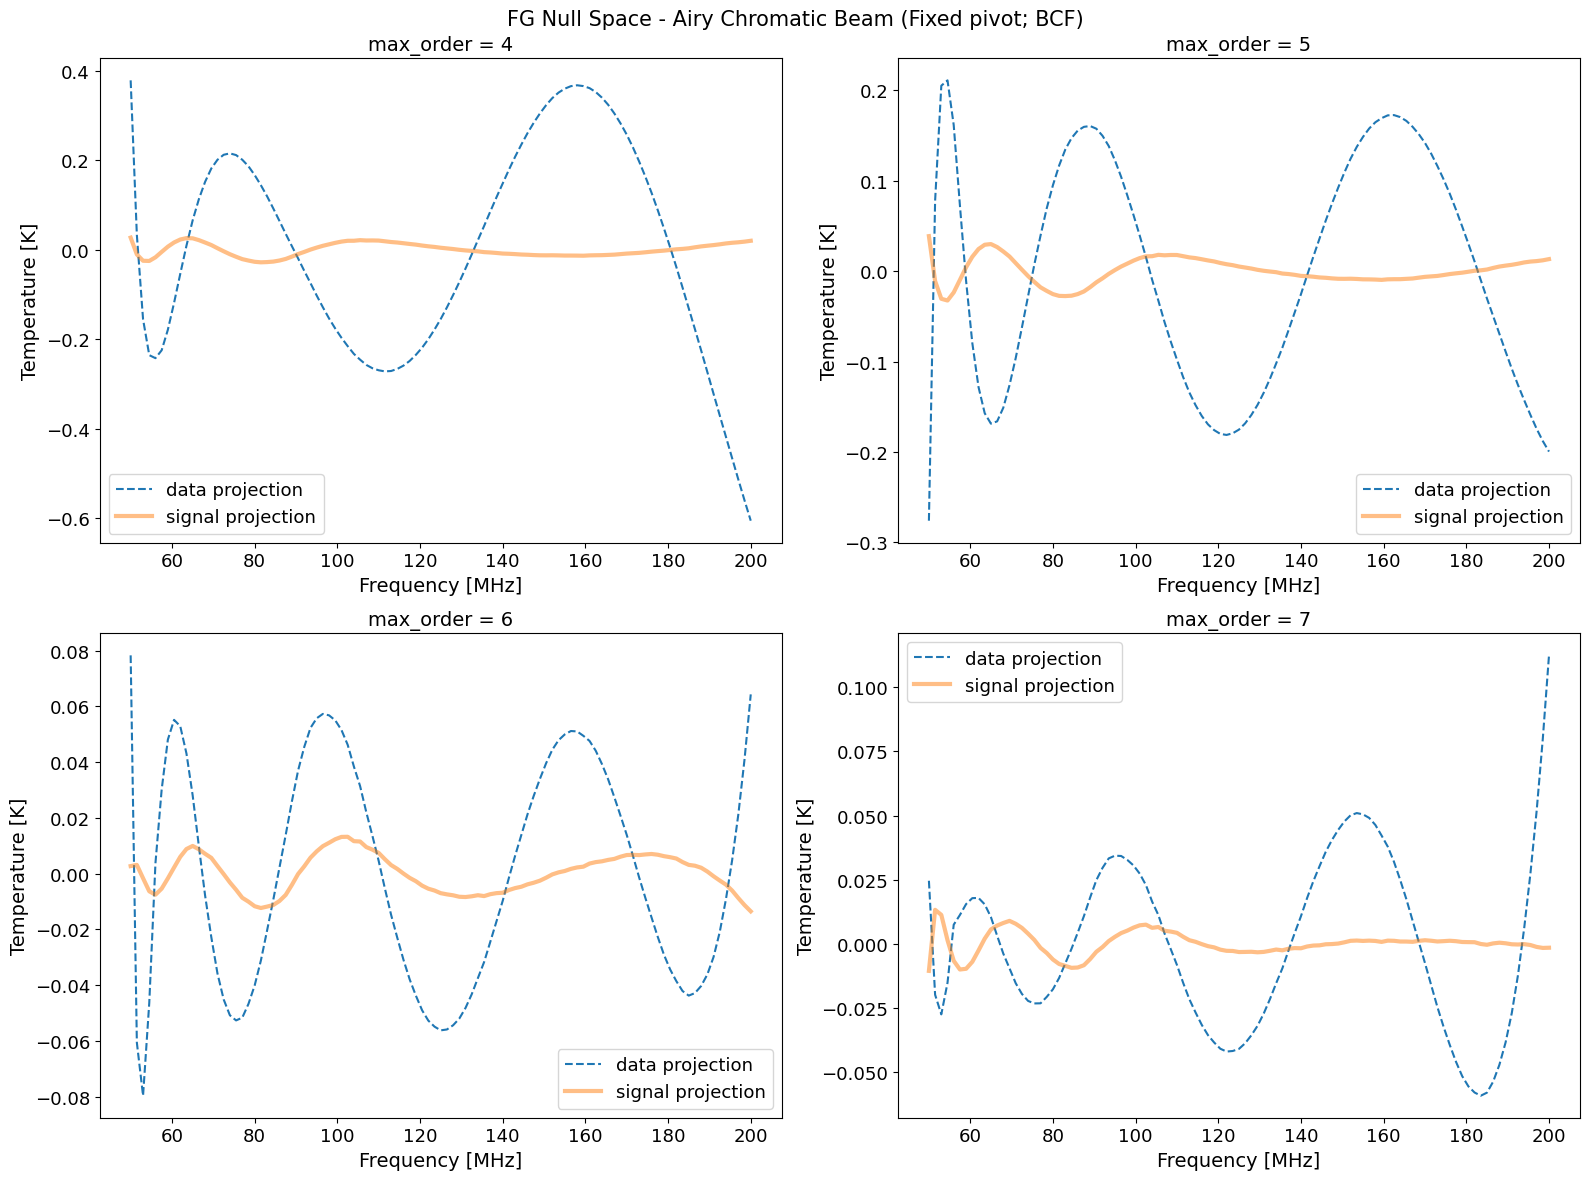

In [129]:
data = Air_TOD + true_signal[np.newaxis,:] + 3
BCFs = Airy_ch_BCF_cube
# BCFs = [None]*212

orders = [[4,5],[6,7]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        data_projs, gs_projs =  projection_in_fg_null_space(GS_object_50_200, data, spec_ind_tod, max_order, true_signal, BCFs)
        ax = axs[i,j]
        ax.plot(freq_list, data_projs[ind], label='data projection', linestyle='--')
        ax.plot(freq_list, gs_projs[ind], label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}'.format(max_order), fontsize=14)
        ax.legend(fontsize=13)
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - Airy Chromatic Beam (Fixed pivot; BCF)', fontsize=15)
plt.tight_layout()
plt.show()





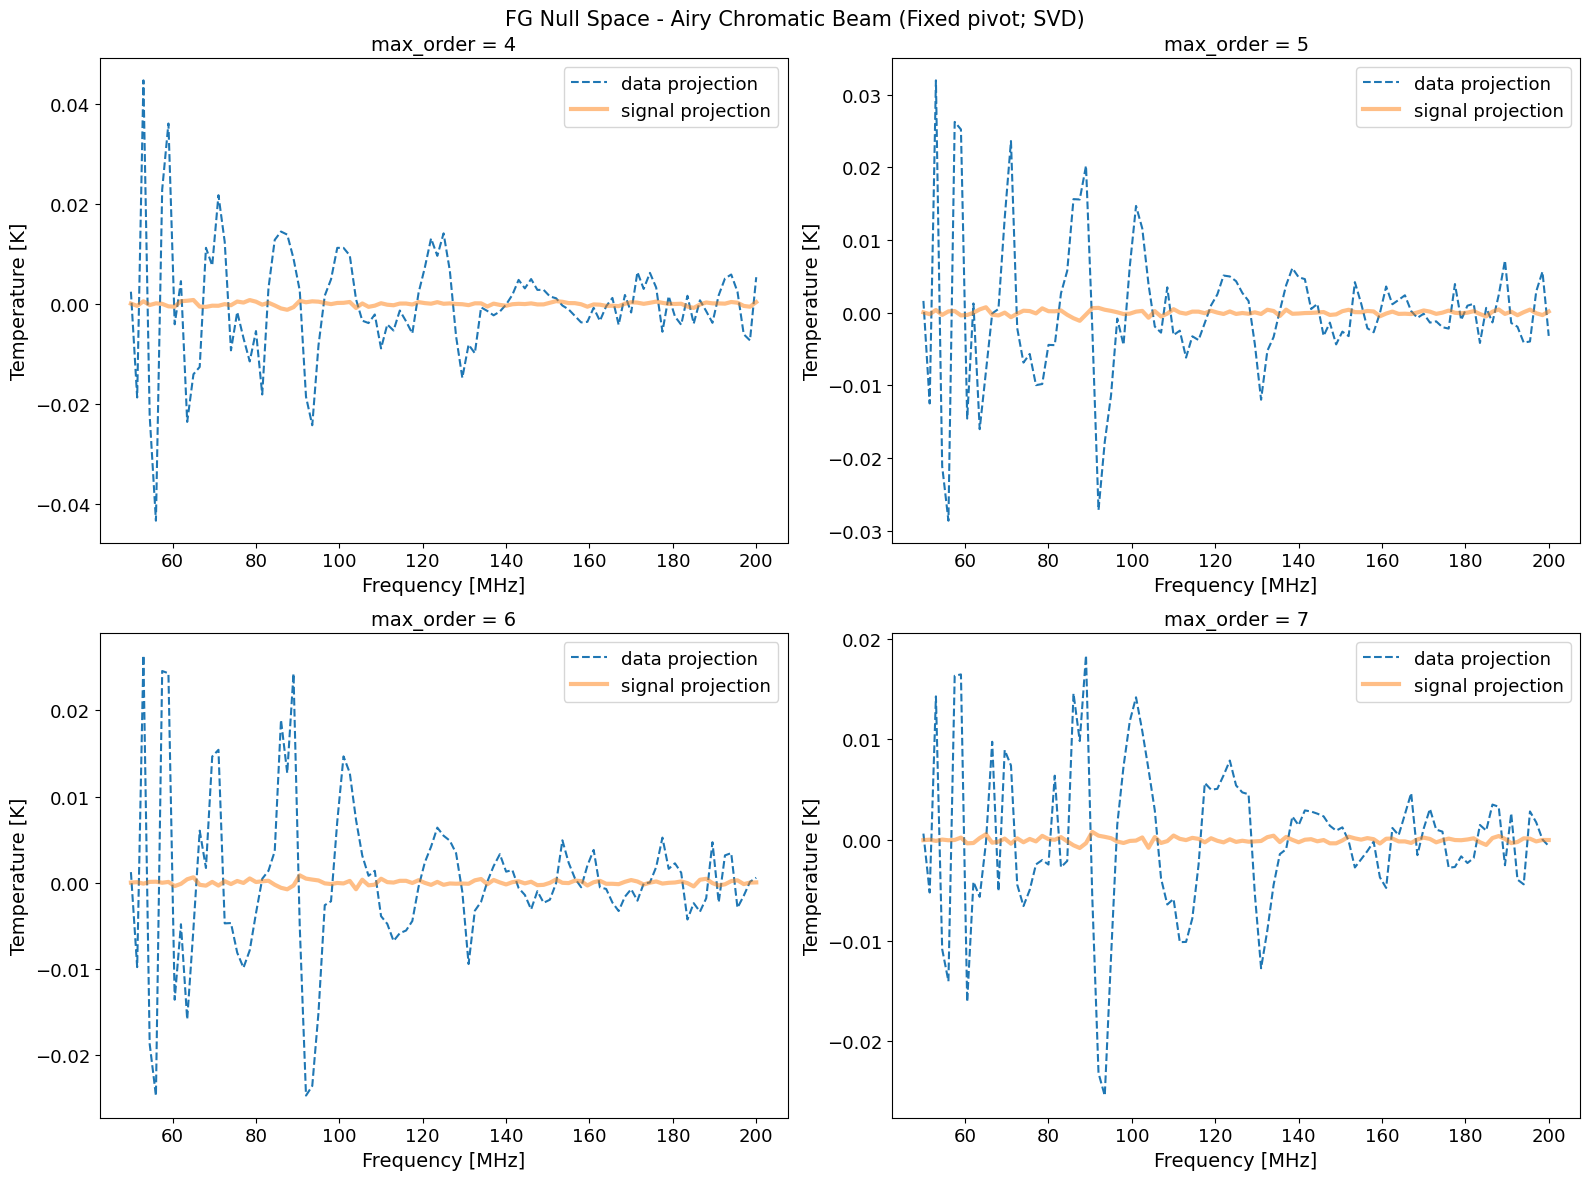

In [136]:
data = Air_TOD + true_signal[np.newaxis,:] + 3
BCFs = Airy_ch_BCF_cube
# BCFs = [None]*212
n_beam = 10

orders = [[4,5],[6,7]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        data_projs, gs_projs =  projection_in_fg_null_space(GS_object_50_200, data, spec_ind_tod, max_order, true_signal, BCSVD=Airy_ch_U[:, :n_beam])
        ax = axs[i,j]
        ax.plot(freq_list, data_projs[ind], label='data projection', linestyle='--')
        ax.plot(freq_list, gs_projs[ind], label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}'.format(max_order), fontsize=14)
        ax.legend(fontsize=13)
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - Airy Chromatic Beam (Fixed pivot; SVD)', fontsize=15)
plt.tight_layout()
plt.show()


In [6]:
freq_list = np.linspace(50, 200, 101)
CNN_PL = Mel_model.map(freq_list) + Mel_ff_model.map(freq_list)


In [8]:
CNN_PL_monopole = np.mean(CNN_PL, axis=0).reshape(1, -1)  # Reshape to ensure it's a 2D array for broadcasting

In [22]:
spec_ind.shape

(1,)

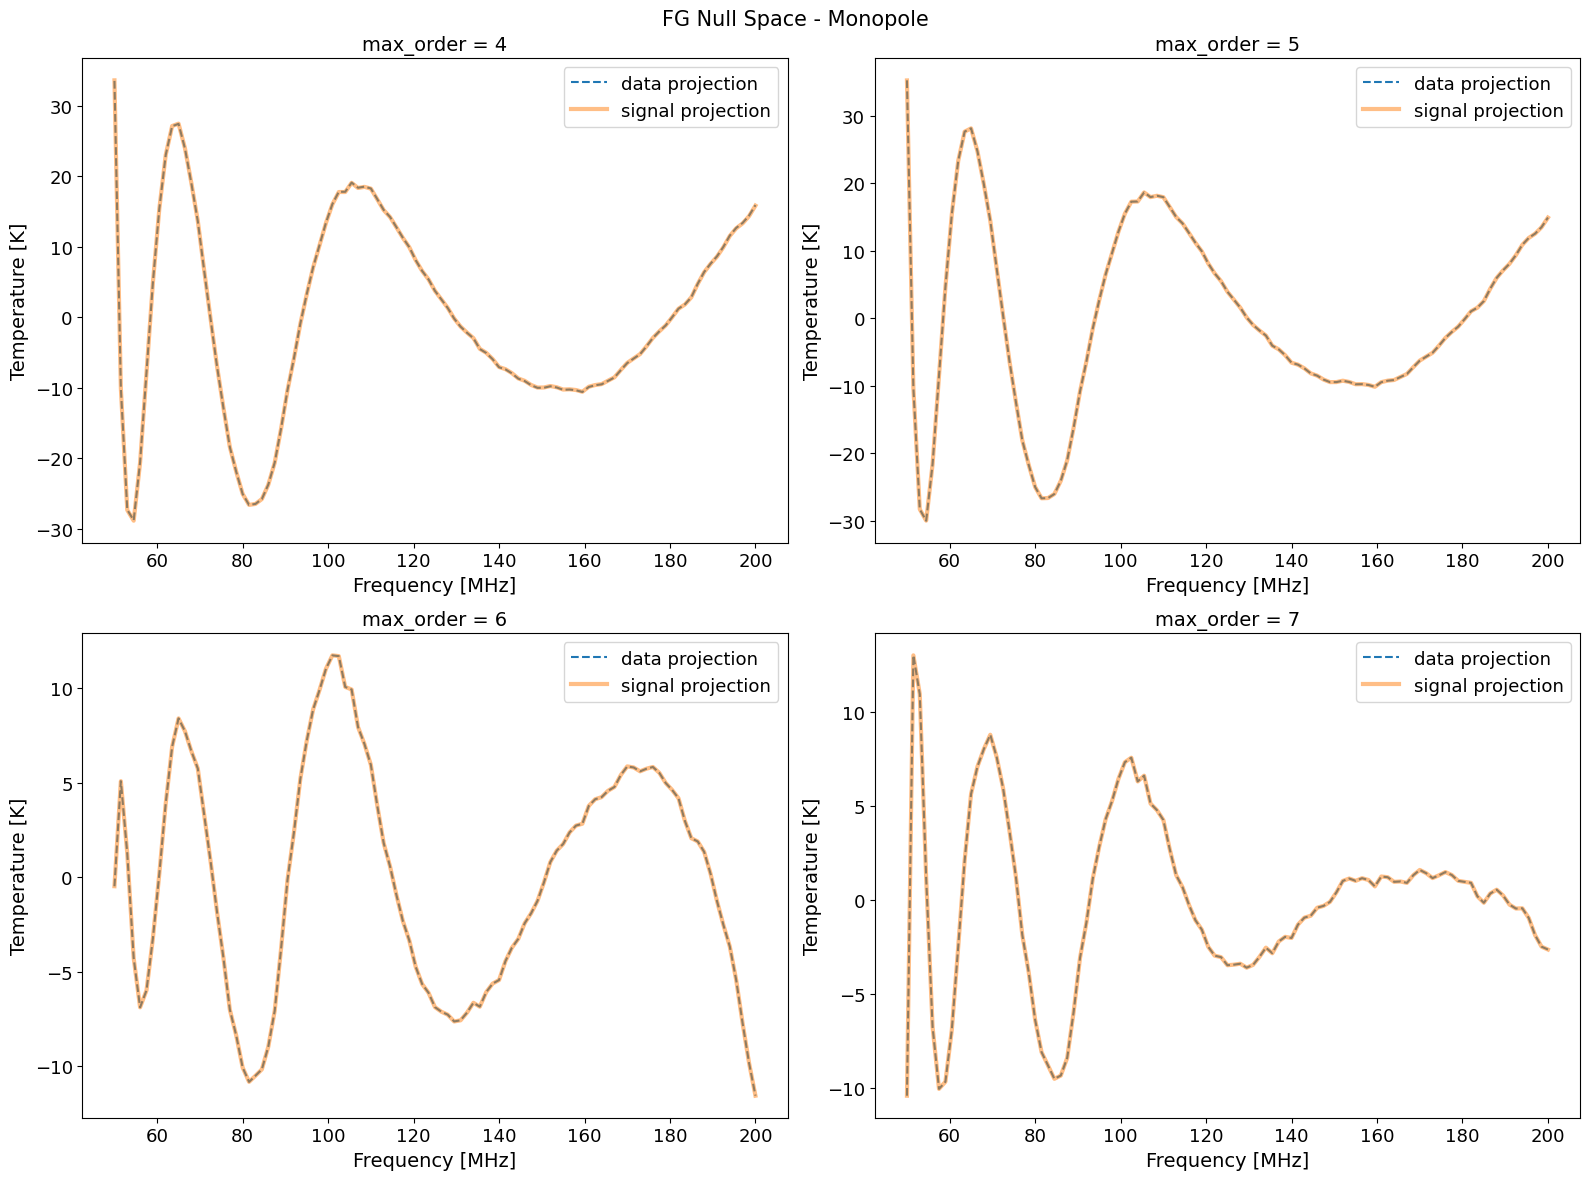

In [23]:
data = CNN_PL_monopole[0] + true_signal + 3
spec_ind = np.mean(Mel_model.specidx_map)  # Reshape to ensure it's a 2D array for broadcasting

def projection_in_fg_null_space_v2(obj, data, beta0, max_order, true_signal):
    '''
    Compute the projection of the data in the null space of the spectral moment basis.
    '''
    ortho_basis = obj.null_space_basis(beta0, max_order)
    proj = ortho_basis @ ortho_basis.T
    # obtain the data[i] projection onto this basis
    data_proj = data @ proj
    true_signal_proj = true_signal @ proj
    return data_proj, true_signal_proj


orders = [[4,5],[6,7]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        data_projs, gs_projs =  projection_in_fg_null_space_v2(GS_object_50_200, data, spec_ind, max_order, true_signal)
        ax = axs[i,j]
        ax.plot(freq_list, data_projs, label='data projection', linestyle='--')
        ax.plot(freq_list, gs_projs, label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}'.format(max_order), fontsize=14)
        ax.legend(fontsize=13)
# Ticks
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - Monopole', fontsize=15)
plt.tight_layout()
plt.show()

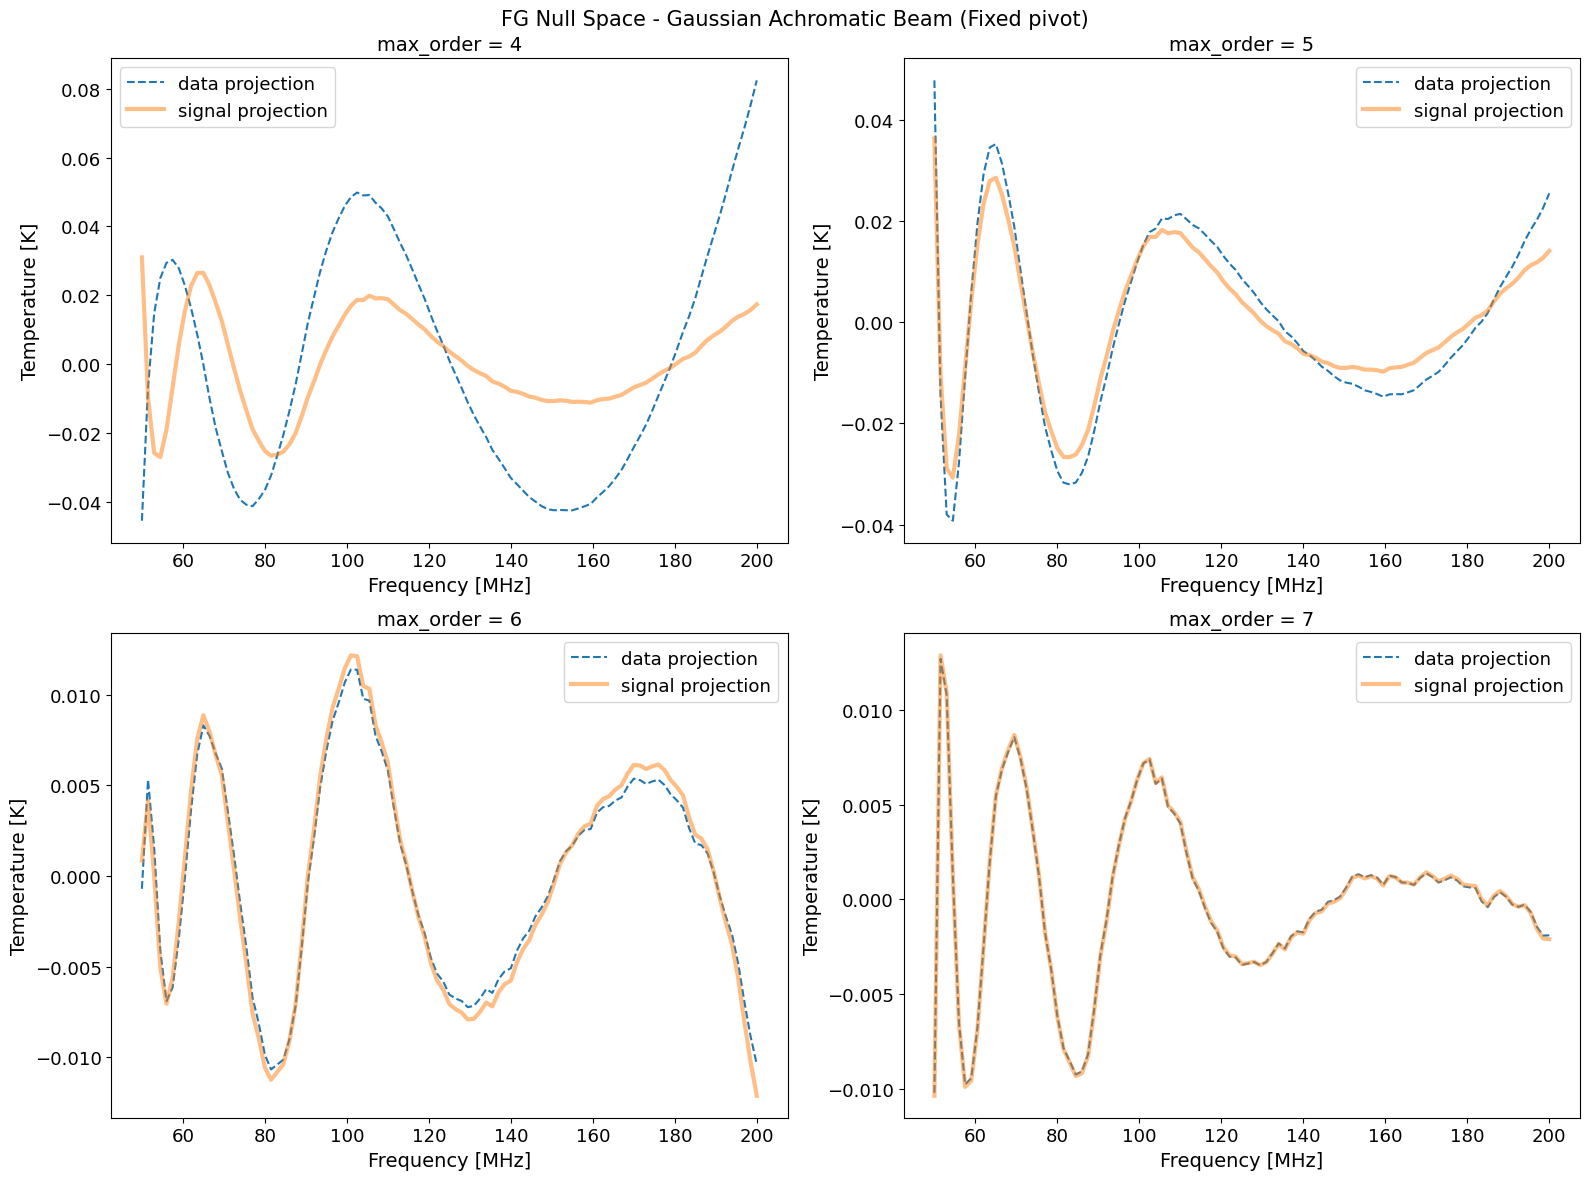

In [121]:
data = Gau_TOD + true_signal[np.newaxis,:] + 3

orders = [[4,5],[6,7]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        data_projs, gs_projs =  projection_in_fg_null_space(GS_object_50_200, data, spec_ind_tod, max_order, true_signal)
        ax = axs[i,j]
        ax.plot(freq_list, data_projs[ind], label='data projection', linestyle='--')
        ax.plot(freq_list, gs_projs[ind], label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}'.format(max_order), fontsize=14)
        ax.legend(fontsize=13)
# Ticks
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - Gaussian Achromatic Beam (Fixed pivot)', fontsize=15)
plt.tight_layout()
plt.show()

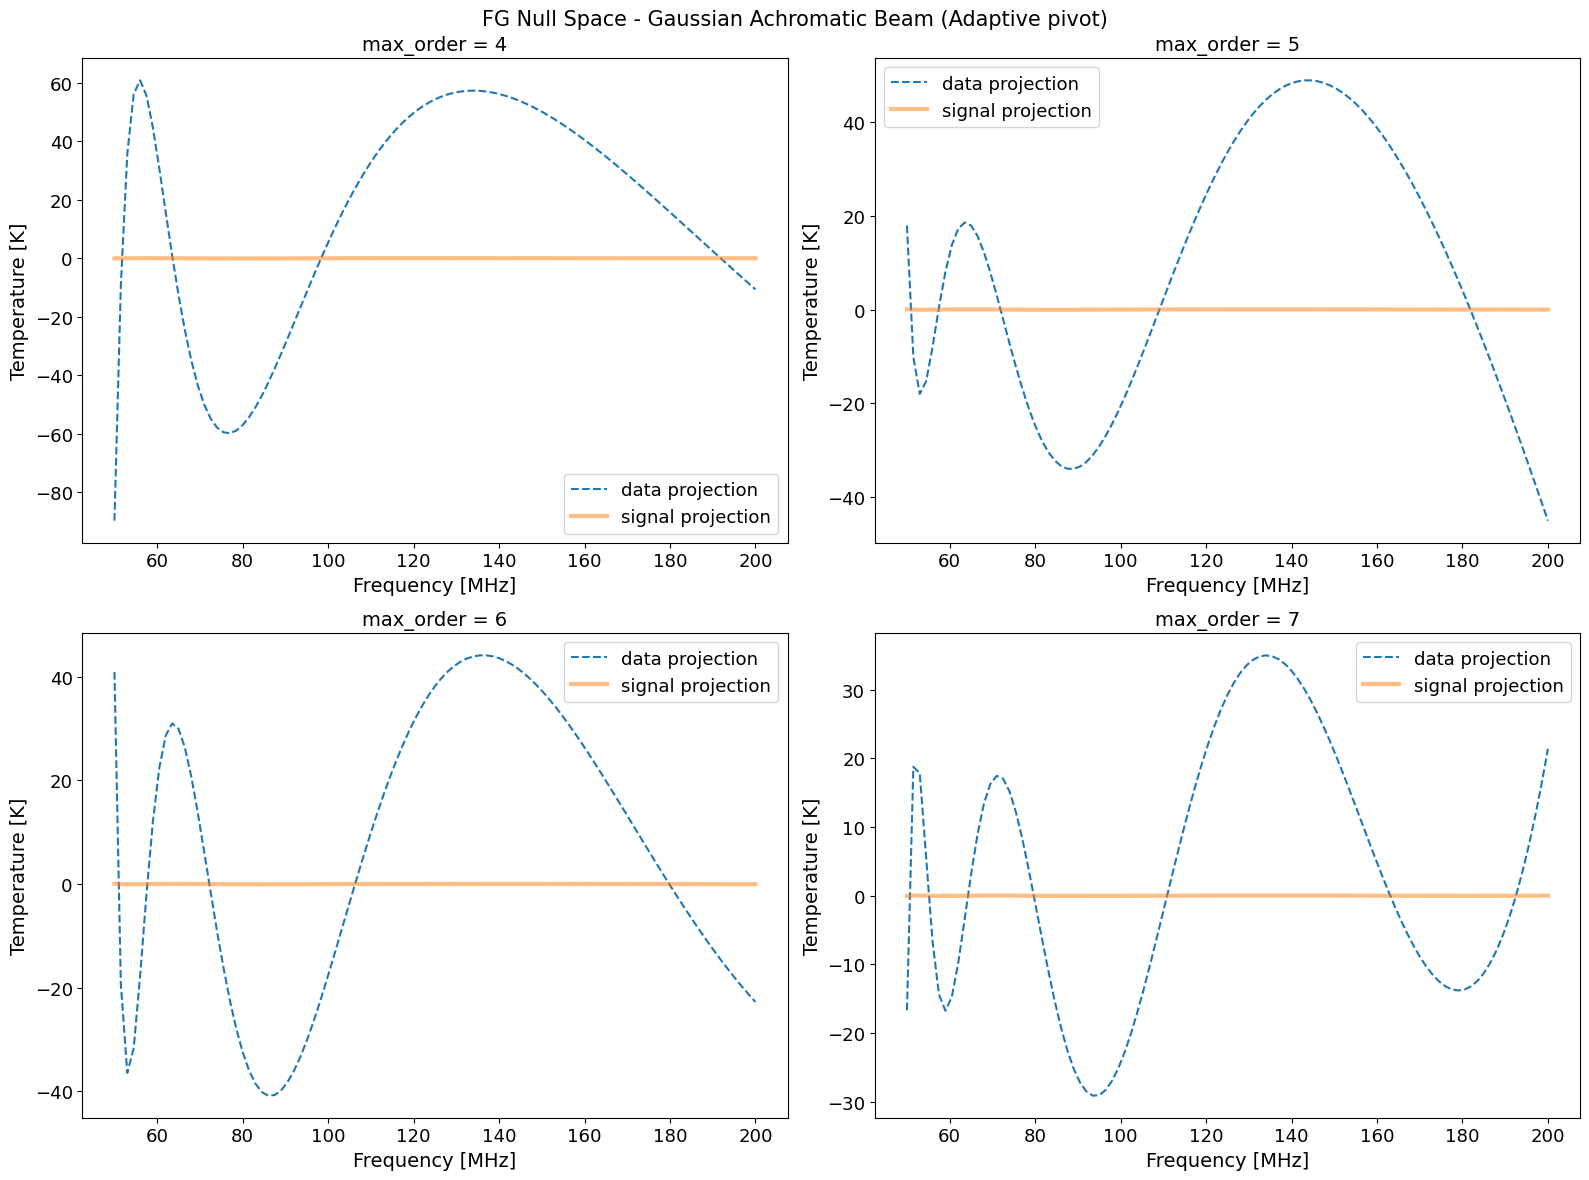

In [123]:
data = Gau_TOD + true_signal[np.newaxis,:] + 3

orders = [[4,5],[6,7]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        data_projs, gs_projs =  projection_in_fg_null_space(GS_object_50_200, data, spec_ind_tod, max_order, true_signal, adaptive_pivot=True)
        ax = axs[i,j]
        ax.plot(freq_list, data_projs[ind], label='data projection', linestyle='--')
        ax.plot(freq_list, gs_projs[ind], label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}'.format(max_order), fontsize=14)
        ax.legend(fontsize=13)
# Ticks
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - Gaussian Achromatic Beam (Adaptive pivot)', fontsize=15)
plt.tight_layout()
plt.show()

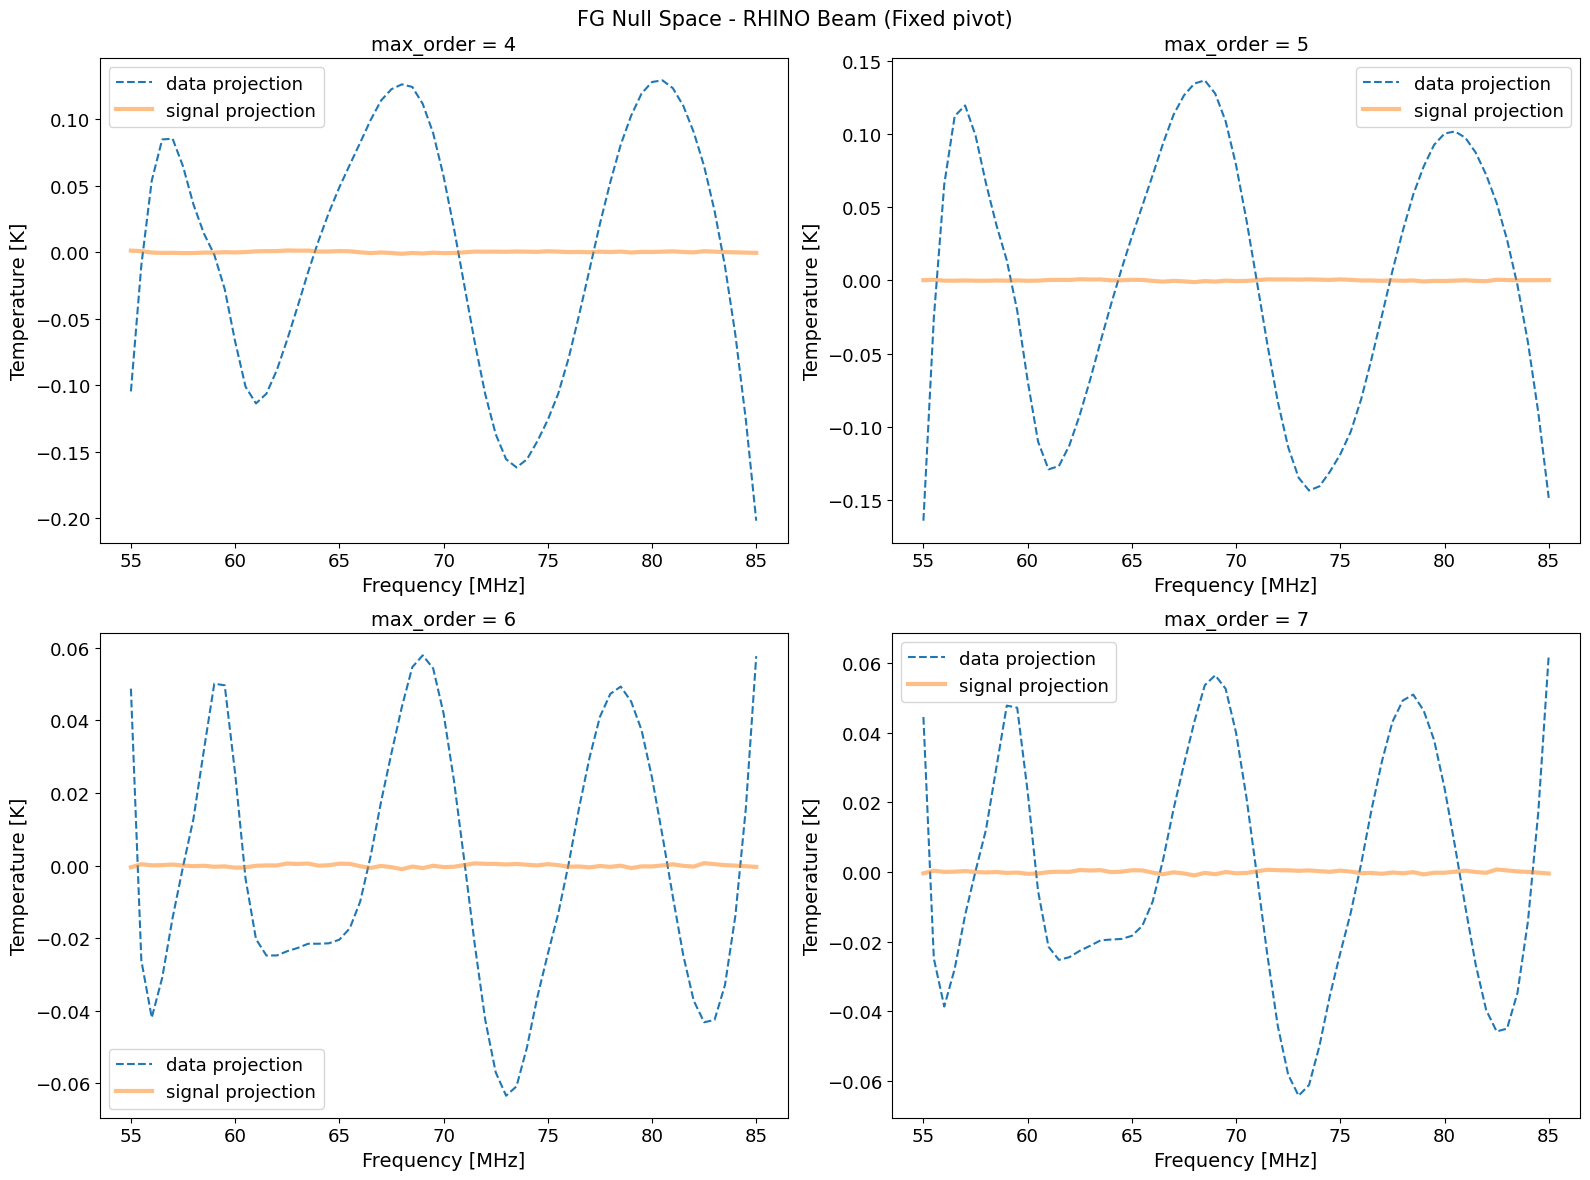

In [135]:
Rhino_true_signal = np.load('global_signal_55_85.npy')
Rhino_true_signal *= 1e-3
data = Rhino_TOD + Rhino_true_signal[np.newaxis,:] + 3

orders = [[4,5],[6,7]]
ind = 1

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

for i in range(2):
    for j in range(2):
        max_order = orders[i][j]
        data_projs, gs_projs =  projection_in_fg_null_space(GS_object_55_85, data, spec_ind_tod, max_order, Rhino_true_signal, BCF_list=RHINO_BCF_cube)
        ax = axs[i,j]
        ax.plot(RHINO_freq_list, data_projs[ind], label='data projection', linestyle='--')
        ax.plot(RHINO_freq_list, gs_projs[ind], label='signal projection', lw=3, alpha=0.5)
        ax.set_ylabel('Temperature [K]', fontsize=14)
        ax.set_xlabel('Frequency [MHz]', fontsize=14)
        ax.set_title('max_order = {}'.format(max_order), fontsize=14)
        ax.legend(fontsize=13)
# Ticks
for ax in axs.flat:
    ax.tick_params(axis='both', which='major', labelsize=13)
plt.suptitle('FG Null Space - RHINO Beam (Fixed pivot)', fontsize=15)
plt.tight_layout()
plt.show()